# MINA: Multilevel Knowledge-Guided Attention for Modeling Electrocardiography Signals

In [1]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm
import pickle as dill

def preprocess_ecg_images(data_path):
    """
    Загружает изображения ЭКГ из папок и создает словарь с данными и метками.
    data_path: путь к корневой папке датасета (например, "/kaggle/input/ecg-analysis/ECG_DATA")
    """
    # Категории и соответствующие метки
    categories = {
        "Normal Person ECG Images (284x12=3408)": 0,  # Нормальные ЭКГ
        "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": 1,  # Аритмия
        "ECG Images of Myocardial Infarction Patients (240x12=2880)": 2,  # Инфаркт миокарда
        "ECG Images of Patient that have History of MI (172x12=2064)": 3   # История инфаркта
    }
    
    all_data = []
    all_labels = []
    
    # Проходим по train и test папкам
    for split in ['train', 'test']:
        split_path = os.path.join(data_path, split)
        for category in categories.keys():
            category_path = os.path.join(split_path, category)
            label = categories[category]
            
            # Загружаем изображения из каждой категории
            for img_name in tqdm(os.listdir(category_path), desc=f"Loading {split}/{category}"):
                img_path = os.path.join(category_path, img_name)
                if img_name.endswith('.jpg'):
                    # Загружаем изображение в оттенках серого
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    # Приводим к единому размеру (например, 224x224)
                    img = cv2.resize(img, (224, 224))
                    all_data.append(img)
                    all_labels.append(label)
    
    # Преобразуем в numpy массивы
    all_data = np.array(all_data)
    all_labels = np.array(all_labels)
    
    # Нормализация данных (0-255 -> 0-1)
    all_data = all_data / 255.0
    
    # Сохраняем в файл в /kaggle/working/
    output_path = '/kaggle/working/ecg_images.pkl'
    res = {'data': all_data, 'label': all_labels}
    with open(output_path, 'wb') as fout:
        dill.dump(res, fout)
    
    print(f"Data shape: {all_data.shape}, Labels shape: {all_labels.shape}")
    return all_data, all_labels

In [3]:
def make_data_ecg_images(data_path, test_size=0.15, val_size=0.15):
    """
    Подготавливает данные изображений ЭКГ: разделяет на train, val, test.
    """
    # Загружаем предварительно обработанные данные из /kaggle/working/
    input_path = '/kaggle/working/ecg_images.pkl'
    with open(input_path, 'rb') as fin:
        res = dill.load(fin)
    
    all_data = res['data']  # (n_samples, 224, 224)
    all_labels = res['label']  # (n_samples,)
    
    # Добавляем канал для совместимости с CNN (n_samples, 1, 224, 224)
    all_data = np.expand_dims(all_data, axis=1)
    
    # Разделяем на train, val, test
    X_temp, X_test, Y_temp, Y_test = train_test_split(
        all_data, all_labels, test_size=test_size, random_state=42, stratify=all_labels
    )
    val_relative_size = val_size / (1 - test_size)
    X_train, X_val, Y_train, Y_val = train_test_split(
        X_temp, Y_temp, test_size=val_relative_size, random_state=42, stratify=Y_temp
    )
    
    print(f"Train: {Counter(Y_train)}, Val: {Counter(Y_val)}, Test: {Counter(Y_test)}")
    print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")
    
    # Сохраняем данные в /kaggle/working/
    output_path = '/kaggle/working/ecg_split.pkl'
    res = {'X_train': X_train, 'Y_train': Y_train, 
           'X_val': X_val, 'Y_val': Y_val, 
           'X_test': X_test, 'Y_test': Y_test}
    with open(output_path, 'wb') as fout:
        dill.dump(res, fout)
    
    return X_train, Y_train, X_val, Y_val, X_test, Y_test

Mina.py

In [11]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import numpy as np
import pickle as dill
from collections import Counter
from time import localtime, strftime
import random

import matplotlib.pyplot as plt
import random
import sys, os
from shutil import copyfile


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, n_classes=4):
        super(Net, self).__init__()
        
        # Сверточные слои для обработки изображений (1 канал, 224x224)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        
        # Пулинг
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.5)
        
        # Полносвязные слои
        # После трех пулингов: 224 / 2^3 = 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, n_classes)
    
    def forward(self, x):
        # x: (batch_size, 1, 224, 224)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Выравнивание для полносвязного слоя
        x = x.view(-1, 128 * 28 * 28)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        
        # Применяем softmax для получения вероятностей
        x = F.softmax(x, dim=1)
        return x

In [7]:
def train(model, optimizer, loss_func, epoch, batch_size, 
          X_train, Y_train, K_train_beat, K_train_rhythm, K_train_freq, 
          log_file):
    """
    X_train: (n_channel, n_sample, n_dim)
    Y_train: (n_sample,)
    
    K_train_beat: (n_channel, n_sample, n_dim)
    K_train_rhythm: (n_channel, n_sample, n_dim/n_split)
    K_train_freq: (n_channel, n_sample)
    """
    model.train()
    
    n_train = len(Y_train)
    
    pred_all = []
    batch_start_idx = 0
    batch_end_idx = 0
    loss_all = []
    for _ in tqdm(range(n_train//batch_size+1), desc="train"):
    # while batch_end_idx < n_train:
        # print('.', end="")
        batch_end_idx = batch_end_idx + batch_size
        if batch_end_idx >= n_train:
            batch_end_idx = n_train
            
        ### input data
        batch_input_0 = Variable(torch.FloatTensor(X_train[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_1 = Variable(torch.FloatTensor(X_train[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_2 = Variable(torch.FloatTensor(X_train[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_3 = Variable(torch.FloatTensor(X_train[3, batch_start_idx: batch_end_idx, :])).cuda()
        
        ### input K_beat
        batch_K_beat_0 = Variable(torch.FloatTensor(K_train_beat[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_1 = Variable(torch.FloatTensor(K_train_beat[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_2 = Variable(torch.FloatTensor(K_train_beat[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_3 = Variable(torch.FloatTensor(K_train_beat[3, batch_start_idx: batch_end_idx, :])).cuda()

        ### input K_rhythm
        batch_K_rhythm_0 = Variable(torch.FloatTensor(K_train_rhythm[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_1 = Variable(torch.FloatTensor(K_train_rhythm[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_2 = Variable(torch.FloatTensor(K_train_rhythm[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_3 = Variable(torch.FloatTensor(K_train_rhythm[3, batch_start_idx: batch_end_idx, :])).cuda()        
        
        ### input K_freq
        batch_K_freq = Variable(torch.FloatTensor(K_train_freq[:, batch_start_idx: batch_end_idx, :])).cuda()  
        
        ### gt
        batch_gt = Variable(torch.LongTensor(Y_train[batch_start_idx: batch_end_idx])).cuda()
        
        pred, _ = model(batch_input_0, batch_input_1, batch_input_2, batch_input_3, 
                        batch_K_beat_0, batch_K_beat_1, batch_K_beat_2, batch_K_beat_3, 
                        batch_K_rhythm_0, batch_K_rhythm_1, batch_K_rhythm_2, batch_K_rhythm_3, 
                        batch_K_freq)
        
        pred_all.append(pred.cpu().data.numpy())
        # print(pred, batch_gt)

        loss = loss_func(pred, batch_gt)
        loss_all.append(loss.cpu().data.numpy())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_start_idx = batch_start_idx + batch_size

    loss_res = np.mean(loss_all)
    print('epoch {0} '.format(epoch))
    print('loss ', np.mean(loss_all))
    print('train | ', end='')
    pred_all = np.concatenate(pred_all, axis=0)
    # print(Y_train.shape, pred_all.shape)
    res = evaluate(Y_train, pred_all)
    res.append(loss_res)
    res.append(pred_all)
    
    with open(log_file, 'a') as fout:
        print('epoch {0} '.format(epoch), 'train | ', res, file=fout)
        print('loss_all ', np.mean(loss_all), file=fout)
        
    return res
    

def test(model, batch_size, 
         X_test, Y_test, K_test_beat, K_test_rhythm, K_test_freq, 
         log_file):
    
    model.eval()
    
    n_test = len(Y_test)
    
    pred_all = []
    att_dic_all = []
    
    batch_start_idx = 0
    batch_end_idx = 0
    for _ in tqdm(range(n_test//batch_size+1), desc="test"):
    # while batch_end_idx < n_test:
        # print('.', end="")
        batch_end_idx = batch_end_idx + batch_size
        if batch_end_idx >= n_test:
            batch_end_idx = n_test
            
        ### input data
        batch_input_0 = Variable(torch.FloatTensor(X_test[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_1 = Variable(torch.FloatTensor(X_test[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_2 = Variable(torch.FloatTensor(X_test[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_input_3 = Variable(torch.FloatTensor(X_test[3, batch_start_idx: batch_end_idx, :])).cuda()
        
        ### input K_beat
        batch_K_beat_0 = Variable(torch.FloatTensor(K_test_beat[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_1 = Variable(torch.FloatTensor(K_test_beat[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_2 = Variable(torch.FloatTensor(K_test_beat[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_beat_3 = Variable(torch.FloatTensor(K_test_beat[3, batch_start_idx: batch_end_idx, :])).cuda()

        ### input K_rhythm
        batch_K_rhythm_0 = Variable(torch.FloatTensor(K_test_rhythm[0, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_1 = Variable(torch.FloatTensor(K_test_rhythm[1, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_2 = Variable(torch.FloatTensor(K_test_rhythm[2, batch_start_idx: batch_end_idx, :])).cuda()
        batch_K_rhythm_3 = Variable(torch.FloatTensor(K_test_rhythm[3, batch_start_idx: batch_end_idx, :])).cuda()
        
        ### input K_freq
        batch_K_freq = Variable(torch.FloatTensor(K_test_freq[:, batch_start_idx: batch_end_idx, :])).cuda()
        
        ### gt
        batch_gt = Variable(torch.LongTensor(Y_test[batch_start_idx: batch_end_idx])).cuda()

        pred, att_dic = model(batch_input_0, batch_input_1, batch_input_2, batch_input_3, 
                              batch_K_beat_0, batch_K_beat_1, batch_K_beat_2, batch_K_beat_3, 
                              batch_K_rhythm_0, batch_K_rhythm_1, batch_K_rhythm_2, batch_K_rhythm_3, 
                              batch_K_freq)
            
        for k, v in att_dic.items():
            att_dic[k] = v.cpu().data.numpy()
        att_dic_all.append(att_dic)
        pred_all.append(pred.cpu().data.numpy())

        batch_start_idx = batch_start_idx + batch_size

    print('test | ', end='')
    pred_all = np.concatenate(pred_all, axis=0)
    res = evaluate(Y_test, pred_all)
    res.append(pred_all)
    
    with open(log_file, 'a') as fout:
        print('test | ', res, file=fout)

    return res, att_dic_all

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix
from collections import OrderedDict

def evaluate(gt, pred):
    """
    Оценивает предсказания модели.
    gt: истинные метки (ground truth), массив целых чисел (0, 1, 2, 3)
    pred: предсказанные вероятности, массив формы (n_samples, n_classes)
    """
    pred_label = np.argmax(pred, axis=1)  # Преобразуем вероятности в метки

    res = OrderedDict()
    
    # Вычисляем метрики
    try:
        # Для многоклассового случая используем 'ovr' (one-vs-rest)
        res['auroc'] = roc_auc_score(gt, pred, multi_class='ovr')
        res['auprc'] = average_precision_score(gt, pred, average='macro')
    except ValueError as e:
        print(f"Warning: AUROC/AUPRC calculation failed: {e}")
        res['auroc'] = 0.0
        res['auprc'] = 0.0
    
    res['f1'] = f1_score(gt, pred_label, average='macro')  # macro для многоклассового случая
    res['confusion_matrix'] = confusion_matrix(gt, pred_label).tolist()  # Матрица ошибок
    
    # Выводим результаты
    for k, v in res.items():
        print(f"{k}: {v}")
    
    return list(res.values())

In [16]:
# Функция обучения и тестирования с графиками
def run(data_path):
    n_epoch = 50
    lr = 0.001
    batch_size = 32
    
    # Создаем директорию для результатов
    run_id = f"ecg_cnn_{strftime('%Y-%m-%d-%H-%M-%S', localtime())}"
    directory = f"/kaggle/working/res/{run_id}"
    os.makedirs(directory, exist_ok=True)
    
    log_file = f"{directory}/log.txt"
    
    # Загружаем данные из /kaggle/working/
    with open('/kaggle/working/ecg_split.pkl', 'rb') as fin:
        res = dill.load(fin)
    X_train, Y_train = res['X_train'], res['Y_train']
    X_val, Y_val = res['X_val'], res['Y_val']
    X_test, Y_test = res['X_test'], res['Y_test']
    
    # Инициализация модели
    torch.manual_seed(0)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Net(n_classes=4).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_func = nn.CrossEntropyLoss()
    
    # Списки для хранения метрик по эпохам
    train_losses = []
    train_aurocs = []
    train_auprcs = []
    train_f1s = []
    val_aurocs = []
    val_auprcs = []
    val_f1s = []
    test_aurocs = []
    test_auprcs = []
    test_f1s = []
    
    # Обучение и тестирование
    for epoch in range(n_epoch):
        model.train()
        train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(Y_train)), 
                                  batch_size=batch_size, shuffle=True)
        loss_all = []
        pred_all = []
        
        for batch_X, batch_Y in tqdm(train_loader, desc=f"Epoch {epoch} - Training"):
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            pred = model(batch_X)
            loss = loss_func(pred, batch_Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_all.append(loss.item())
            pred_all.append(pred.cpu().detach().numpy())
        
        pred_all = np.concatenate(pred_all)
        train_loss = np.mean(loss_all)
        print(f"Epoch {epoch}, Loss: {train_loss}")
        train_res = evaluate(Y_train, pred_all)
        
        # Сохраняем метрики для тренировочной выборки
        train_losses.append(train_loss)
        train_aurocs.append(train_res[0])  # AUROC
        train_auprcs.append(train_res[1])  # AUPRC
        train_f1s.append(train_res[2])     # F1-score
        
        # Валидация
        model.eval()
        val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(Y_val)), 
                                batch_size=batch_size)
        pred_all = []
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X = batch_X.to(device)
                pred = model(batch_X)
                pred_all.append(pred.cpu().numpy())
        pred_all = np.concatenate(pred_all)
        val_res = evaluate(Y_val, pred_all)
        
        # Сохраняем метрики для валидационной выборки
        val_aurocs.append(val_res[0])
        val_auprcs.append(val_res[1])
        val_f1s.append(val_res[2])
        
        # Тестирование
        test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(Y_test)), 
                                 batch_size=batch_size)
        pred_all = []
        with torch.no_grad():
            for batch_X, batch_Y in test_loader:
                batch_X = batch_X.to(device)
                pred = model(batch_X)
                pred_all.append(pred.cpu().numpy())
        pred_all = np.concatenate(pred_all)
        test_res = evaluate(Y_test, pred_all)
        
        # Сохраняем метрики для тестовой выборки
        test_aurocs.append(test_res[0])
        test_auprcs.append(test_res[1])
        test_f1s.append(test_res[2])
        
        # Логирование
        with open(log_file, 'a') as fout:
            print(f"Epoch {epoch} - Train: {train_res[:3]}, Val: {val_res[:3]}, Test: {test_res[:3]}", file=fout)
    
    # Сохранение модели
    torch.save(model.state_dict(), f"{directory}/model_final.pt")
    
    # Построение графиков
    epochs = range(n_epoch)
    
    plt.figure(figsize=(15, 10))
    
    # График Loss
    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    
    # График AUROC
    plt.subplot(2, 2, 2)
    plt.plot(epochs, train_aurocs, label='Train AUROC')
    plt.plot(epochs, val_aurocs, label='Val AUROC')
    plt.plot(epochs, test_aurocs, label='Test AUROC')
    plt.xlabel('Epoch')
    plt.ylabel('AUROC')
    plt.title('AUROC over Epochs')
    plt.legend()
    plt.grid(True)
    
    # График AUPRC
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_auprcs, label='Train AUPRC')
    plt.plot(epochs, val_auprcs, label='Val AUPRC')
    plt.plot(epochs, test_auprcs, label='Test AUPRC')
    plt.xlabel('Epoch')
    plt.ylabel('AUPRC')
    plt.title('AUPRC over Epochs')
    plt.legend()
    plt.grid(True)
    
    # График F1-score
    plt.subplot(2, 2, 4)
    plt.plot(epochs, train_f1s, label='Train F1-score')
    plt.plot(epochs, val_f1s, label='Val F1-score')
    plt.plot(epochs, test_f1s, label='Test F1-score')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.title('F1-score over Epochs')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"{directory}/training_metrics.png")
    plt.show()

### main.py

Loading train/Normal Person ECG Images (284x12=3408): 100%|██████████| 852/852 [00:13<00:00, 63.83it/s]
Loading train/ECG Images of Patient that have abnormal heartbeat (233x12=2796): 100%|██████████| 699/699 [00:11<00:00, 62.00it/s]
Loading train/ECG Images of Myocardial Infarction Patients (240x12=2880): 100%|██████████| 956/956 [00:15<00:00, 60.69it/s]
Loading train/ECG Images of Patient that have History of MI (172x12=2064): 100%|██████████| 516/516 [00:08<00:00, 61.43it/s]
Loading test/Normal Person ECG Images (284x12=3408): 100%|██████████| 284/284 [00:04<00:00, 63.88it/s]
Loading test/ECG Images of Patient that have abnormal heartbeat (233x12=2796): 100%|██████████| 233/233 [00:03<00:00, 61.18it/s]
Loading test/ECG Images of Myocardial Infarction Patients (240x12=2880): 100%|██████████| 239/239 [00:03<00:00, 60.29it/s]
Loading test/ECG Images of Patient that have History of MI (172x12=2064): 100%|██████████| 172/172 [00:02<00:00, 62.25it/s]


Data shape: (3951, 224, 224), Labels shape: (3951,)
Train: Counter({2: 836, 0: 795, 1: 652, 3: 482}), Val: Counter({2: 180, 0: 170, 1: 140, 3: 103}), Test: Counter({2: 179, 0: 171, 1: 140, 3: 103})
X_train shape: (2765, 1, 224, 224), X_val shape: (593, 1, 224, 224), X_test shape: (593, 1, 224, 224)


Epoch 0 - Training: 100%|██████████| 87/87 [00:03<00:00, 22.79it/s]


Epoch 0, Loss: 1.443504678791967
auroc: 0.0
auprc: 0.0
f1: 0.12306970916765116
confusion_matrix: [[11, 0, 784, 0], [10, 0, 642, 0], [5, 0, 831, 0], [6, 0, 476, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11642949547218628
confusion_matrix: [[0, 0, 170, 0], [0, 0, 140, 0], [0, 0, 180, 0], [0, 0, 103, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11593264248704663
confusion_matrix: [[0, 0, 171, 0], [0, 0, 140, 0], [0, 0, 179, 0], [0, 0, 103, 0]]


Epoch 1 - Training: 100%|██████████| 87/87 [00:03<00:00, 22.84it/s]


...

Epoch 47, Loss: 1.4407557002429305
auroc: 0.0
auprc: 0.0
f1: 0.11607886698139407
confusion_matrix: [[0, 0, 795, 0], [0, 0, 652, 0], [0, 0, 836, 0], [0, 0, 482, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11642949547218628
confusion_matrix: [[0, 0, 170, 0], [0, 0, 140, 0], [0, 0, 180, 0], [0, 0, 103, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11593264248704663
confusion_matrix: [[0, 0, 171, 0], [0, 0, 140, 0], [0, 0, 179, 0], [0, 0, 103, 0]]


Epoch 48 - Training: 100%|██████████| 87/87 [00:03<00:00, 22.71it/s]


Epoch 48, Loss: 1.440755702983374
auroc: 0.0
auprc: 0.0
f1: 0.11607886698139407
confusion_matrix: [[0, 0, 795, 0], [0, 0, 652, 0], [0, 0, 836, 0], [0, 0, 482, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11642949547218628
confusion_matrix: [[0, 0, 170, 0], [0, 0, 140, 0], [0, 0, 180, 0], [0, 0, 103, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11593264248704663
confusion_matrix: [[0, 0, 171, 0], [0, 0, 140, 0], [0, 0, 179, 0], [0, 0, 103, 0]]


Epoch 49 - Training: 100%|██████████| 87/87 [00:03<00:00, 22.83it/s]


Epoch 49, Loss: 1.4418056627799725
auroc: 0.0
auprc: 0.0
f1: 0.11607886698139407
confusion_matrix: [[0, 0, 795, 0], [0, 0, 652, 0], [0, 0, 836, 0], [0, 0, 482, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11642949547218628
confusion_matrix: [[0, 0, 170, 0], [0, 0, 140, 0], [0, 0, 180, 0], [0, 0, 103, 0]]
auroc: 0.0
auprc: 0.0
f1: 0.11593264248704663
confusion_matrix: [[0, 0, 171, 0], [0, 0, 140, 0], [0, 0, 179, 0], [0, 0, 103, 0]]


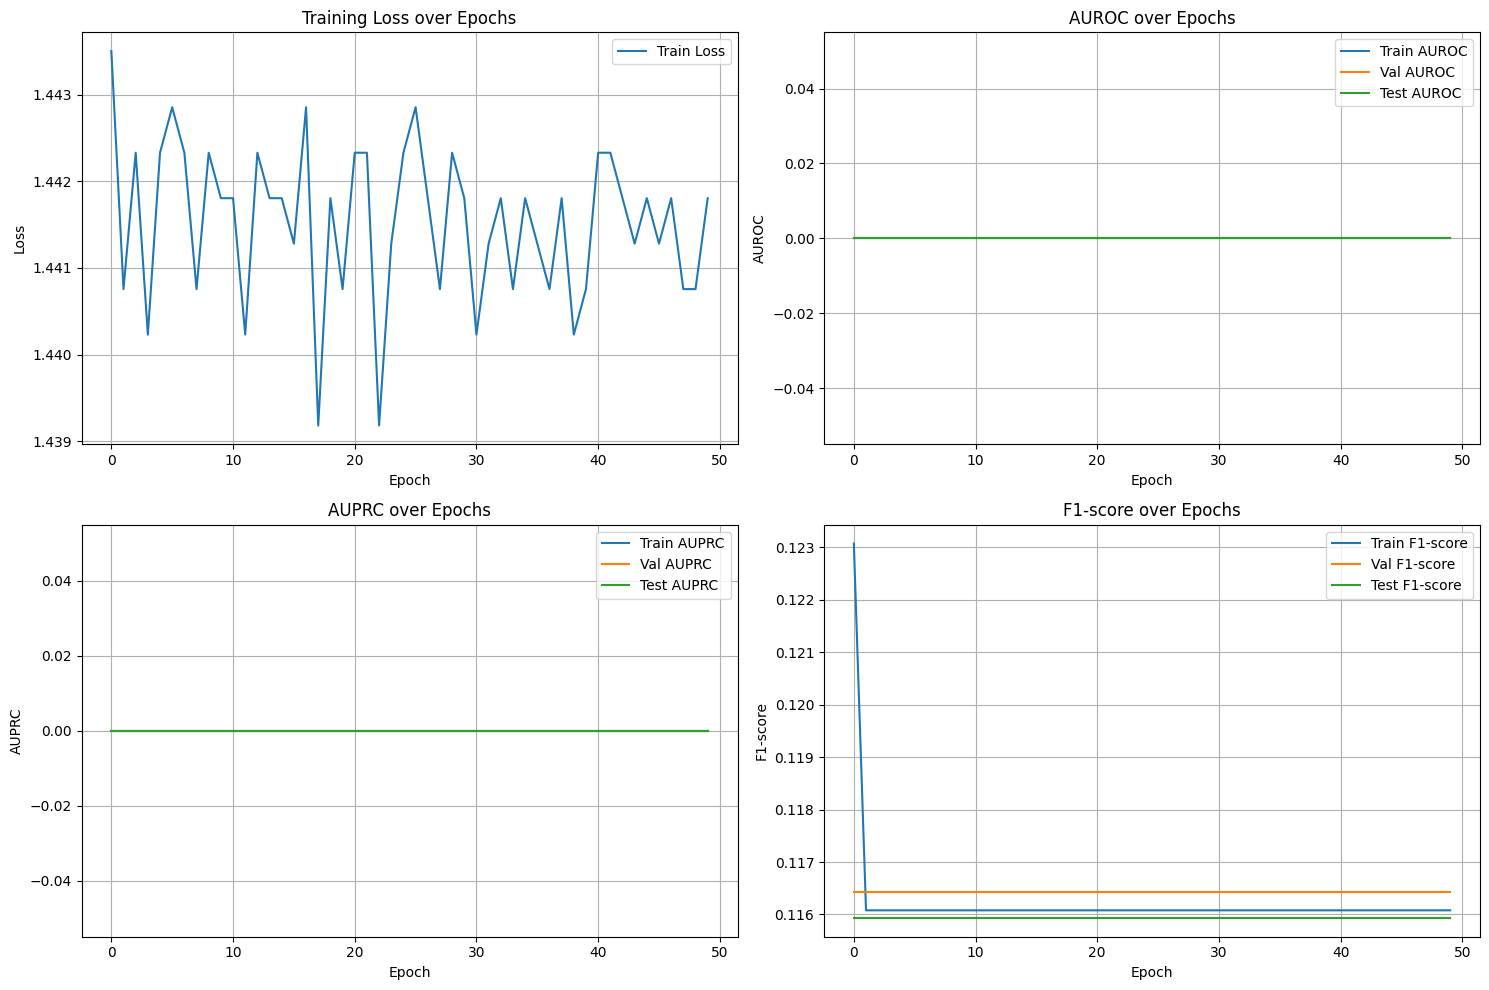

In [17]:
if __name__ == "__main__":
    data_path = "/kaggle/input/ecg-analysis/ECG_DATA"
    
    # Подготовка данных
    preprocess_ecg_images(data_path)  # Загружаем и обрабатываем изображения
    make_data_ecg_images(data_path)   # Разделяем на train/val/test
    
    # Запуск обучения
    run(data_path)

@inproceedings{hong2019mina,
  title={{MINA:} Multilevel Knowledge-Guided Attention for Modeling Electrocardiography Signals},
  author={Hong, Shenda and Xiao, Cao and Ma, Tengfei and Li, Hongyan and Sun, Jimeng},
  booktitle = {IJCAI 2019},
  pages={5888--5894}
}